In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars
##############################################################

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_
##############################################################

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
##############################################################
                    
def setrandomcontrol(control_, max_cntrl_, min_cntrl_, cntrl_vars_):
    for n in range(control_.shape[0]):
        for v in range(control_.shape[1]):
            if v in cntrl_vars_:
                mean_cntrl = np.mean( [max_cntrl_[v], min_cntrl_[v]] )
                control_[n,v,1] = mean_cntrl
                for t in range(2, control_.shape[2]-1):
                    control_[n,v,t] = control_[n,v,t-1] + 0.01 * mean_cntrl * random.uniform(-1, 1)
                    
    return control_
##############################################################
                    
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl    

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

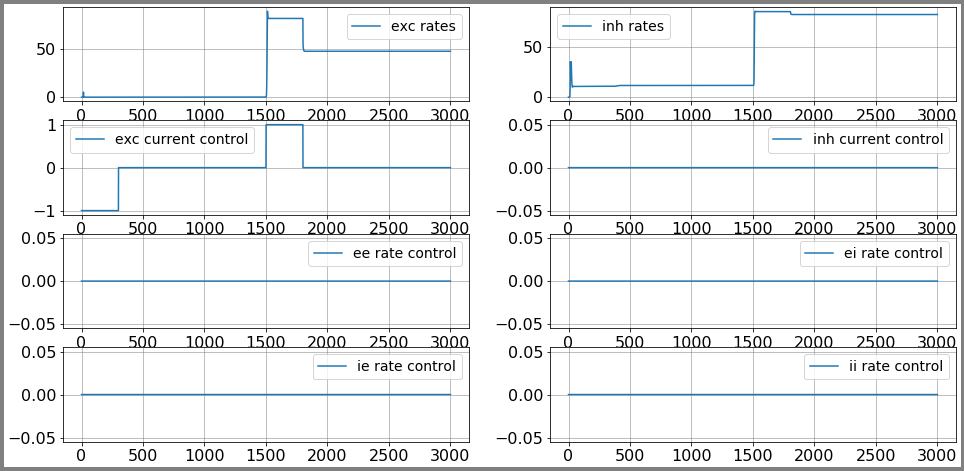

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


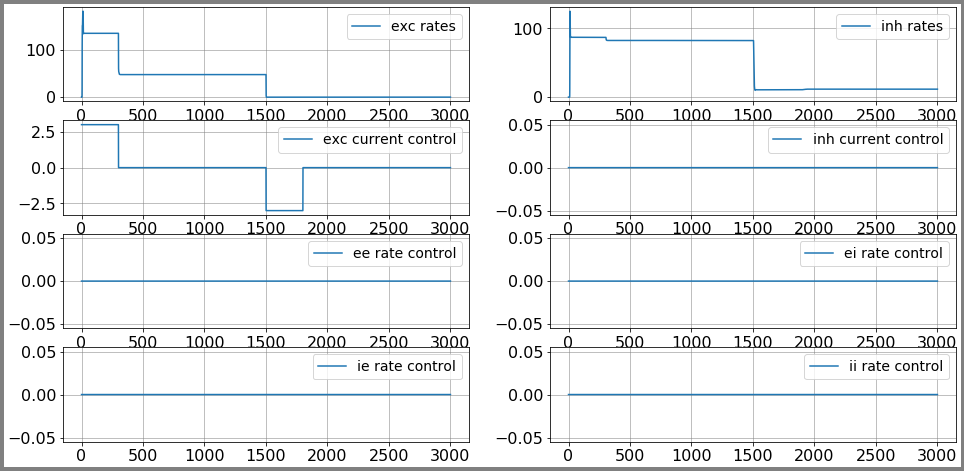

In [3]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]
        
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]


In [4]:
# 8 cases
# ee, ei, ie, ii
c_var = [ [0], [1], [0,1], [2], [3], [4], [5], [2,3,4,5] ]
p_var = [ [0], [0], [0], [0], [0], [0], [0], [0] ]

bestControla = [ [], [], [], [], [], [], [], [], [], [], [], [] ]
bestStatea = [ [], [], [], [], [], [], [], [], [], [], [], [] ]
costa = [ 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0. ]
runtimea = [ 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0. ]
grada = [ [], [], [], [], [], [], [], [], [], [], [], [] ]
phia= [ [], [], [], [], [], [], [], [], [], [], [], [] ]

bestControlb = [ [], [], [], [], [], [], [], [], [], [], [], []]
bestStateb = [ [], [], [], [], [], [], [], [], [], [], [], [] ]
costb = [ 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0. ]
runtimeb = [ 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0. ]
gradb = [ [], [], [], [], [], [], [], [], [], [], [], []]
phib= [ [], [], [], [], [], [], [], [], [], [], [], []]

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

trans_time_array = np.zeros(( len(c_var) ))
trans_time_array[:] = 0.8

target_rates = np.array( [steady_rates[0,0], steady_rates[0,1]])
initVars = low_state_vars

dur = 100
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

sheet = "state_switching"
max_it = 1000

### Cases

Numer | Input | Input label | Result
---------|--------------|-----------|-----------
1 | E current | 0 | 0
2 | I current | 1 | 0
3 | E + I current | 0,1 | 0
4 | EE rate | 2 | 0
5 | EI rate | 3 | 0
6 | IE rate | 4 | 0
7 | II rate | 5 | 0
8 | EE + EI + IE + II rate | 2,3,4,5 | 0

## 1

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  2949.072608149174
RUN  2 , total integrated cost =  1778.9203660693015
RUN  3 , total integrated cost =  89.15108951247882
RUN  4 , total integrated cost =  21.38238446628905
RUN  5 , total integrated cost =  9.302117816895592
RUN  6 , total integrated cost =  5.400643216093798
RUN  7 , total integrated cost =  3.6216180163576244
RUN  8 , total integrated cost =  2.5974319033783986
RUN  9 , total integrated cost =  1.9441276854019511
RUN  10 , total integrated cost =  1.5263339942531167
RUN  11 , total integrated cost =  1.2425486610332994
RUN  12 , total integrated cost =  1.0310405867183763
RUN  13 , total integrated cost =  0.8636988660672524
RUN  14 , total integrated cost =  0.735332655717568
RUN  15 , total integrated cost =  0.639349041016721
RUN  16 , total integr

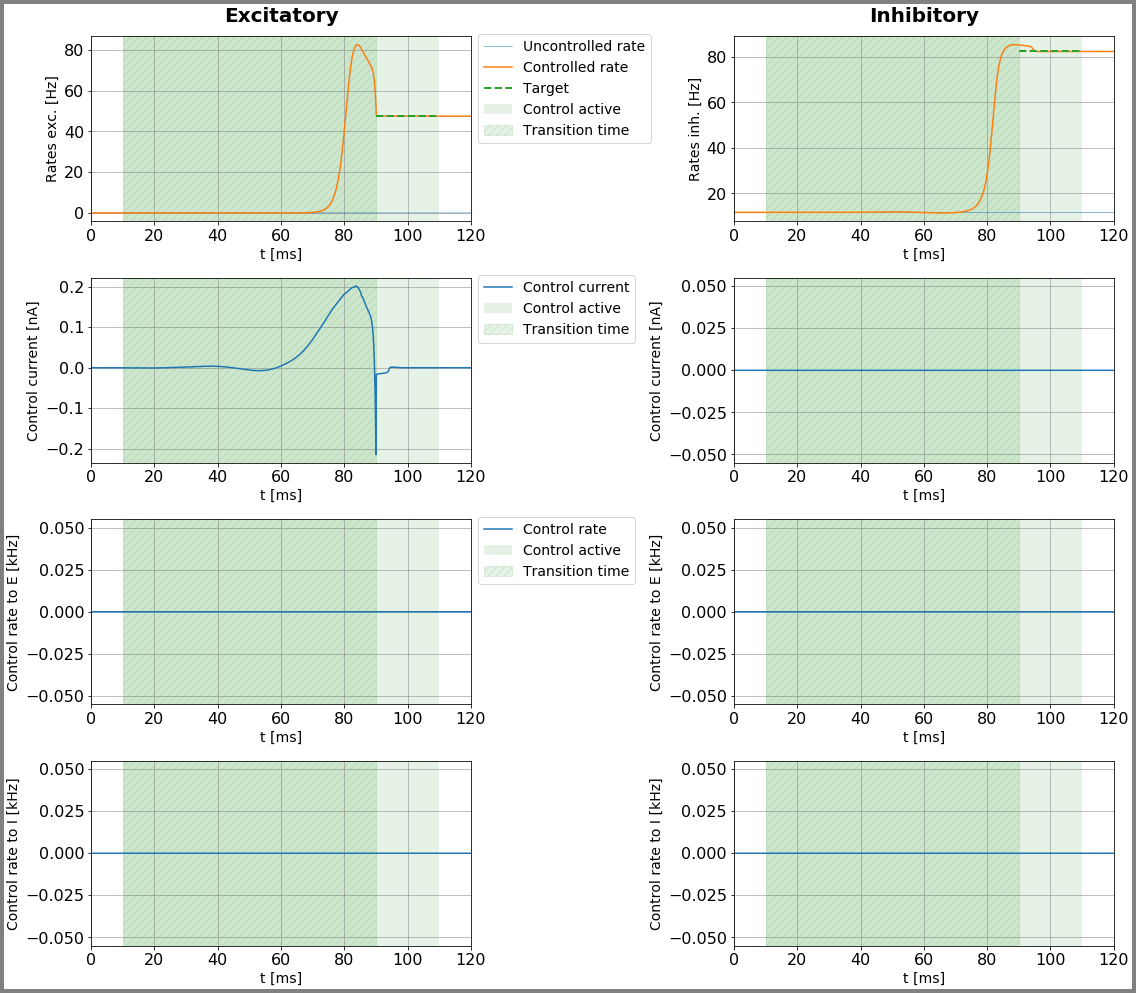

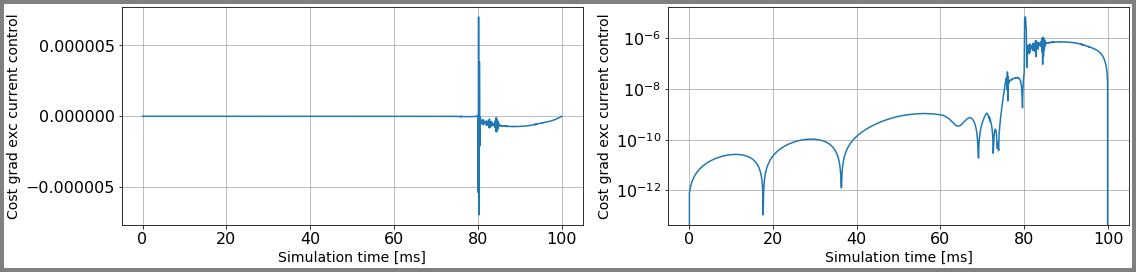

In [6]:
c_ = 0
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(control0,
    target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  100.57559808425788
Gradient descend method:  None
RUN  1 , total integrated cost =  100.57558720787496
RUN  2 , total integrated cost =  100.57558472863451
RUN  3 , total integrated cost =  100.57558206967326
RUN  4 , total integrated cost =  100.57558071829746
RUN  5 , total integrated cost =  100.57557892283938
RUN  6 , total integrated cost =  100.57557749308856
RUN  7 , total integrated cost =  100.57557555034192
RUN  8 , total integrated cost =  100.57557451018698
RUN  9 , total integrated cost =  100.57557288571763
RUN  10 , total integrated cost =  100.57557199539586
RUN  11 , total integrated cost =  100.57557056166891
RUN  12 , total integrated cost =  100.57556983697619
RUN  13 , total integrated cost =  100.5755685439406
RUN  14 , total integrated cost =  100.57556792277255
RUN  15 , total integrated cost =  100.57556634226577
RUN  16 , total 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  217 , total integrated cost =  100.56813876975255
Improved over  217  iterations in  6.790964799999983  seconds by  0.007416624556469742  percent.
Problem in initial value trasfer:  Vmean_exc -56.174593232982225 -56.174593082534216


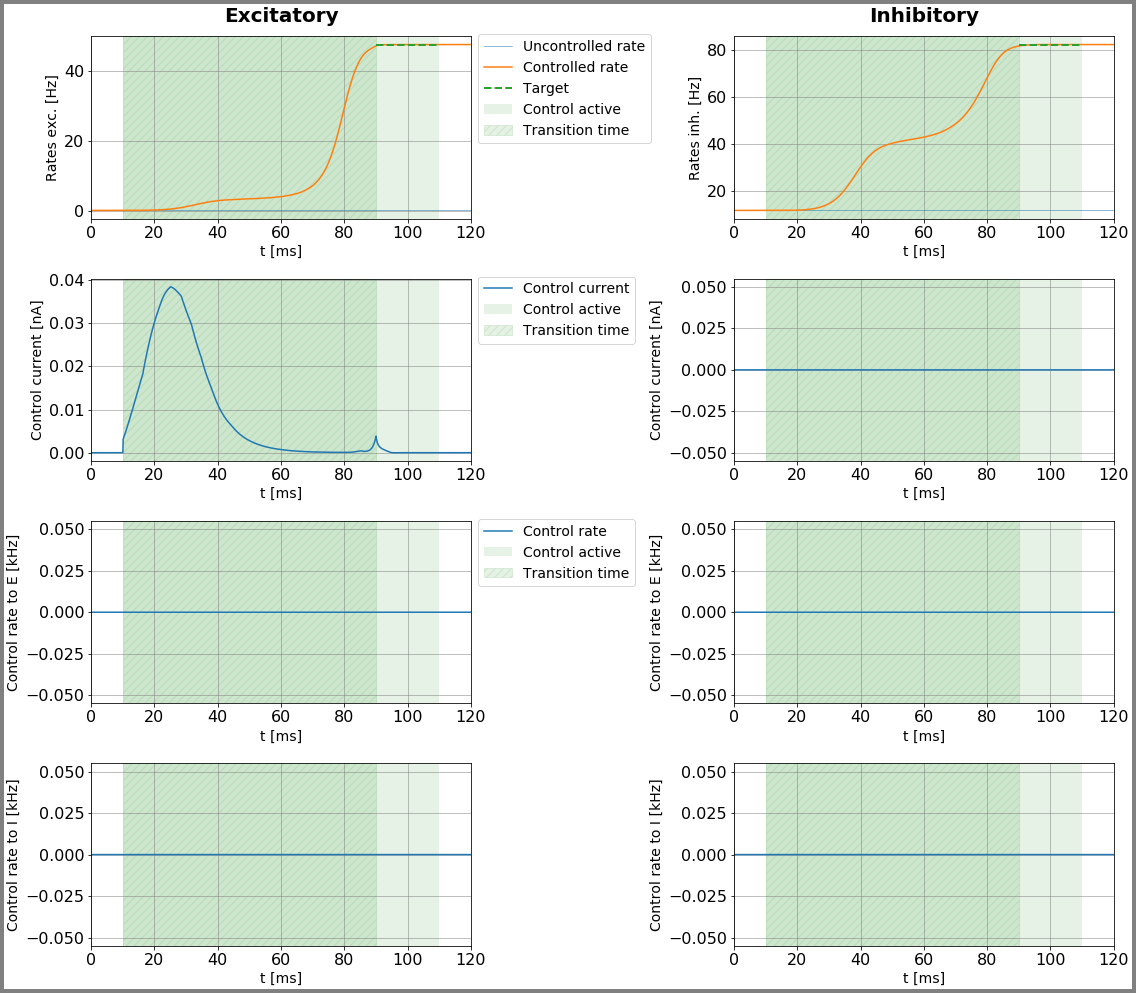

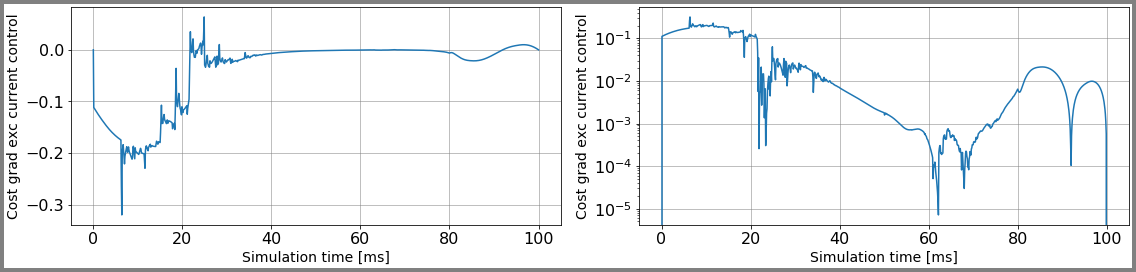

In [10]:
c_ = 0
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 2

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  3859.672296503376
RUN  2 , total integrated cost =  88.30540409162167
RUN  3 , total integrated cost =  1.2412311560575862
RUN  4 , total integrated cost =  0.0598230614877892
RUN  5 , total integrated cost =  0.029961637979352862
RUN  6 , total integrated cost =  0.002949038737146899
RUN  7 , total integrated cost =  0.0015037102635284587
RUN  8 , total integrated cost =  0.0011131193937577847
RUN  9 , total integrated cost =  0.0008873623634675265
RUN  10 , total integrated cost =  0.0007342924806327018
RUN  11 , total integrated cost =  0.0006198705246234058
RUN  12 , total integrated cost =  0.000528319977673254
RUN  13 , total integrated cost =  0.00045085164027131844
RUN  14 , total integrated cost =  0.00038826517153170214
RUN  15 , total integrated cost =  0.00033

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  8.326046583743515e-08
RUN  1000 , total integrated cost =  8.326046583743515e-08
Improved over  1000  iterations in  44.991175299999995  seconds by  99.99999999962985  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459399763963 -56.174597782292906


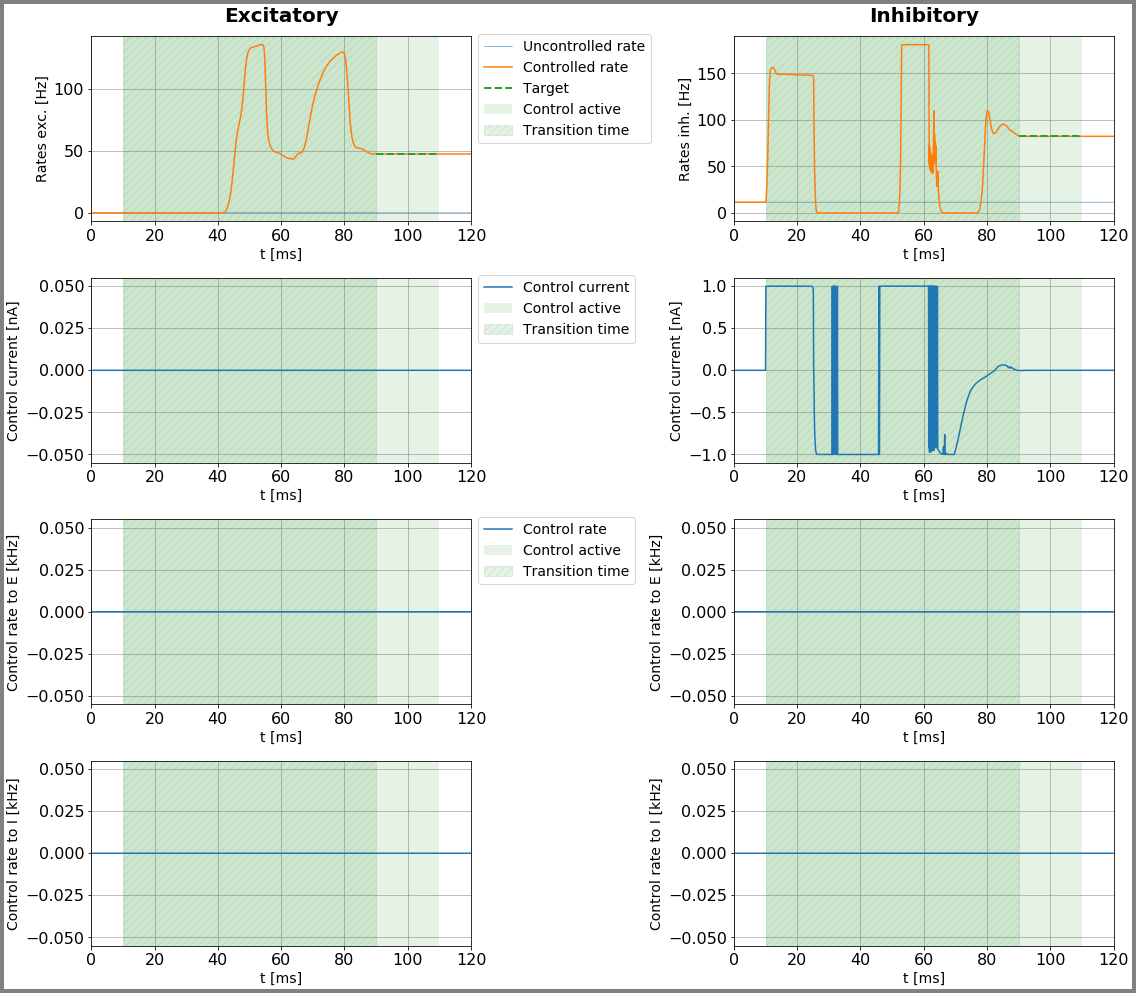

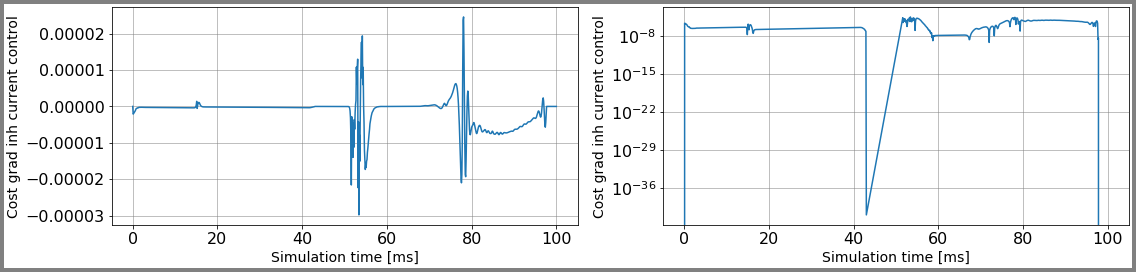

In [6]:
c_ = 1
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  49.276830223167224
Gradient descend method:  None
RUN  1 , total integrated cost =  49.276825799703964
RUN  2 , total integrated cost =  49.276821819847406
RUN  3 , total integrated cost =  49.27681706417292
RUN  4 , total integrated cost =  49.27681383502755
RUN  5 , total integrated cost =  49.276809477443734
RUN  6 , total integrated cost =  49.27680621738836
RUN  7 , total integrated cost =  49.27680183687054
RUN  8 , total integrated cost =  49.27679819006436
RUN  9 , total integrated cost =  49.27679379232039
RUN  10 , total integrated cost =  49.2767896588758
RUN  11 , total integrated cost =  49.27678512293626
RUN  12 , total integrated cost =  49.276780196035936
RUN  13 , total integrated cost =  49.27677402488268
RUN  14 , total integrated cost =  49.27676931208566
RUN  15 , total integrated cost =  49.27676367193696
RUN  16 , total integrated 

ERROR:root:Problem in initial value trasfer


RUN  400 , total integrated cost =  49.249595079419514
Control only changes marginally.
RUN  402 , total integrated cost =  49.2495950794195
Improved over  402  iterations in  13.009718700000008  seconds by  0.05526967466124688  percent.
Problem in initial value trasfer:  Vmean_exc -56.174590291275145 -56.1745903293553


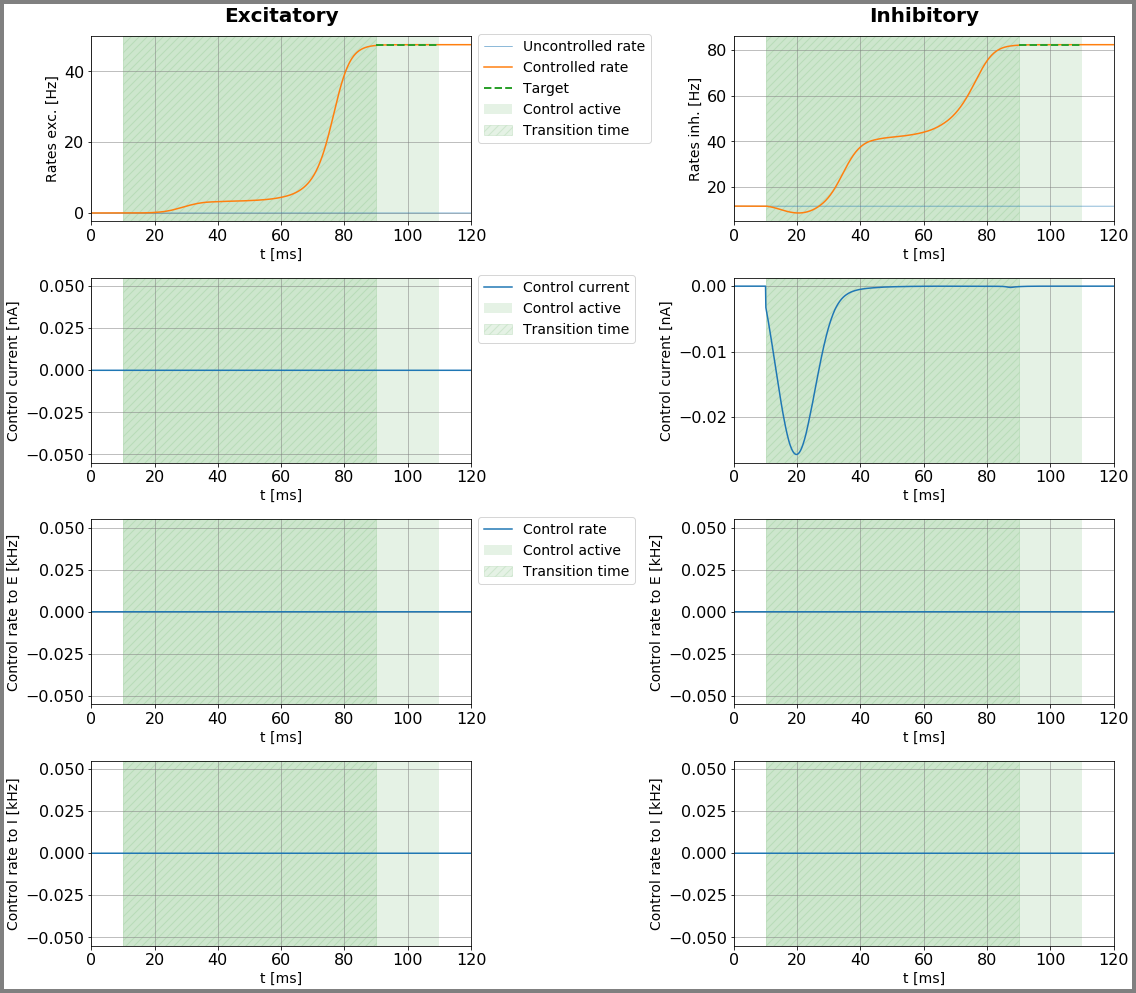

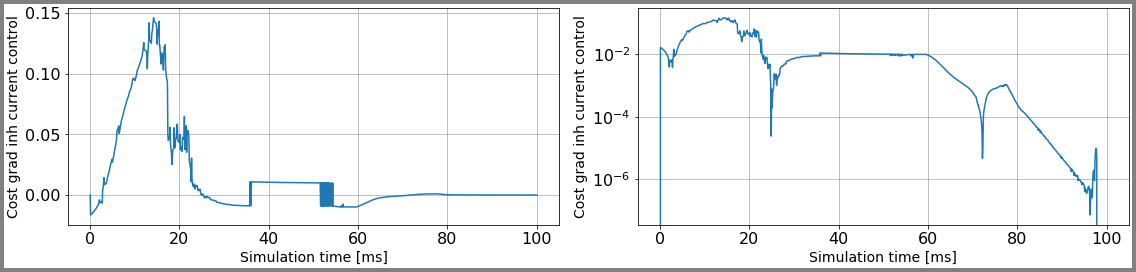

In [10]:
c_ = 1
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 3

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.00046238711798886074
Gradient descend method:  None
RUN  1 , total integrated cost =  0.00046064403876964024
RUN  2 , total integrated cost =  0.0004588882572344964
RUN  3 , total integrated cost =  0.0004568312865888593
RUN  4 , total integrated cost =  0.00045482293585553035
RUN  5 , total integrated cost =  0.00045308205802639515
RUN  6 , total integrated cost =  0.00045138464605564365
RUN  7 , total integrated cost =  0.0004498043791043695
RUN  8 , total integrated cost =  0.0004481396962713234
RUN  9 , total integrated cost =  0.00044654833329319226
RUN  10 , total integrated cost =  0.0004449186049443487
RUN  11 , total integrated cost =  0.0004433186856825952
RUN  12 , total integrated cost =  0.00044172255646110145
RUN  13 , total integrated cost =  0.00044011514708403927
RUN  14 , total integrated cost =  0.0004385513236910595
RUN  15 , tot

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  1.0927865889703862e-05
RUN  1000 , total integrated cost =  1.0927865889703862e-05
Improved over  1000  iterations in  70.31547849999998  seconds by  97.63664136292674  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459009568749 -56.174585490235934


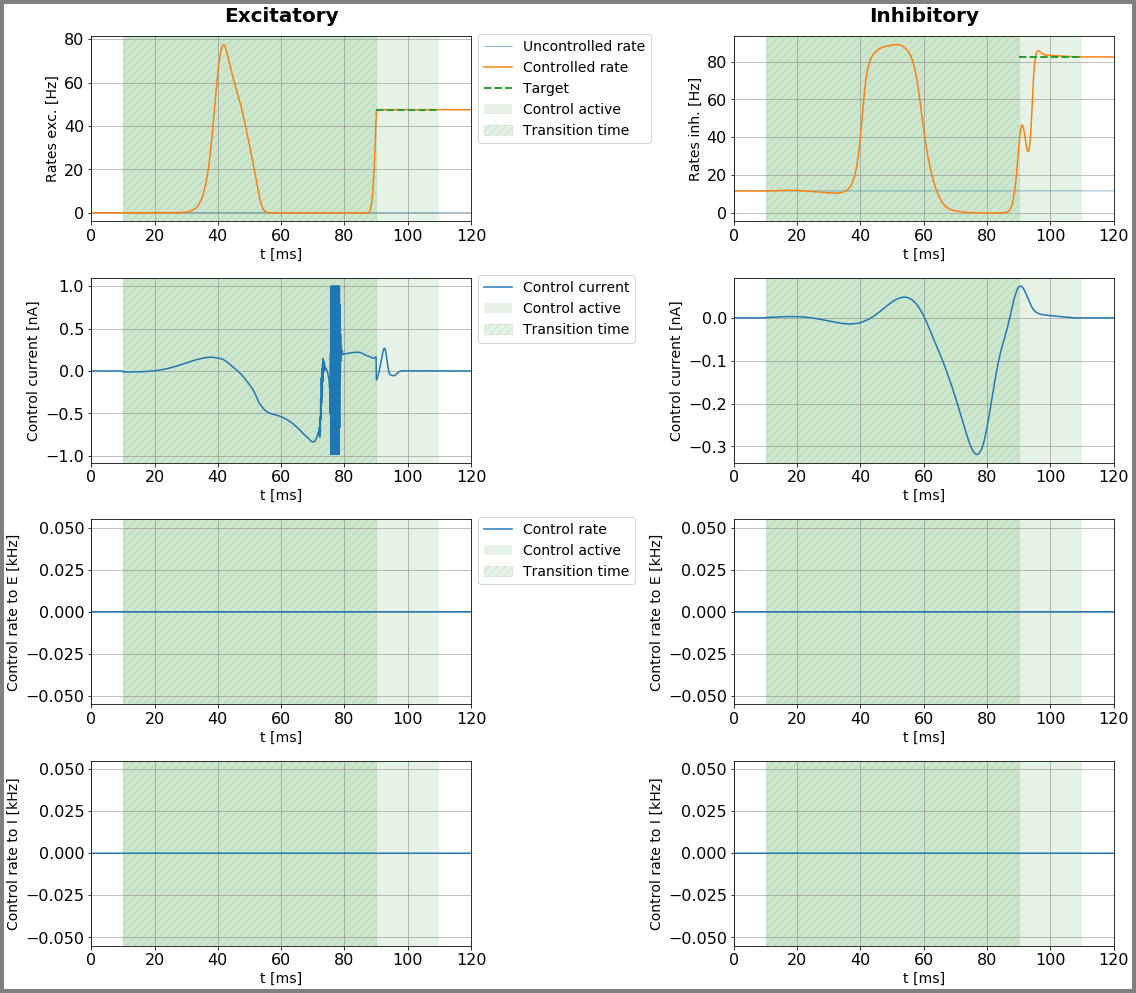

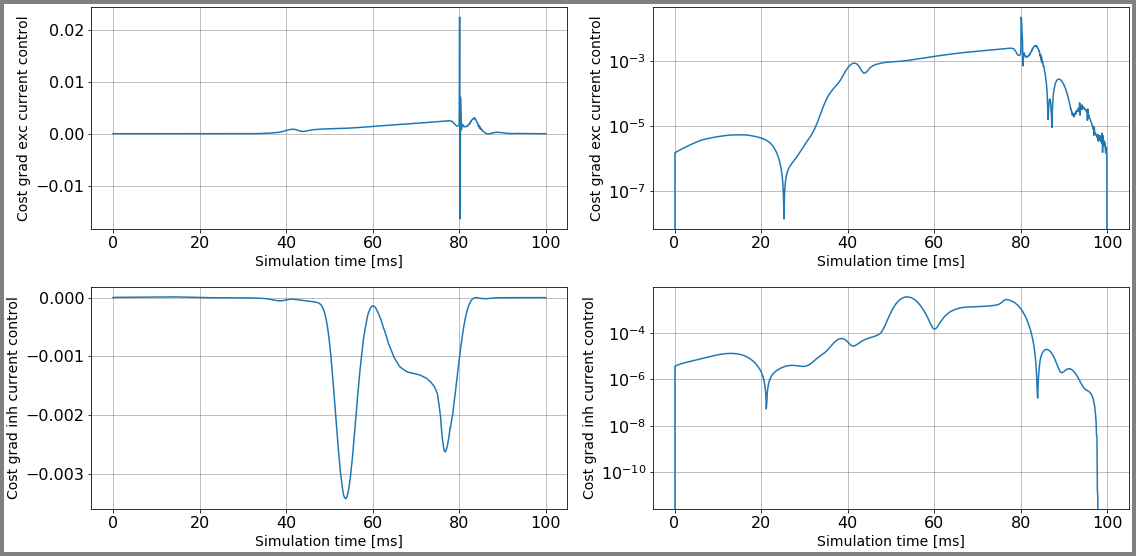

In [7]:
c_ = 2
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  49.40544208371104
Gradient descend method:  None
RUN  1 , total integrated cost =  49.405434204863695
RUN  2 , total integrated cost =  49.40542349623098
RUN  3 , total integrated cost =  49.40541586762507
RUN  4 , total integrated cost =  49.4054067860953
RUN  5 , total integrated cost =  49.4053989200004
RUN  6 , total integrated cost =  49.405388815509255
RUN  7 , total integrated cost =  49.405381409778386
RUN  8 , total integrated cost =  49.405371072451935
RUN  9 , total integrated cost =  49.40536392205618
RUN  10 , total integrated cost =  49.40535428647201
RUN  11 , total integrated cost =  49.40534712841734
RUN  12 , total integrated cost =  49.405337101511506
RUN  13 , total integrated cost =  49.40533025446027
RUN  14 , total integrated cost =  49.40532082775491
RUN  15 , total integrated cost =  49.40531401914366
RUN  16 , total integrate

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  863 , total integrated cost =  49.36036327337245
Improved over  863  iterations in  117.47114590000001  seconds by  0.09124260089041059  percent.
Problem in initial value trasfer:  Vmean_exc -56.174589609670996 -56.17458967396198


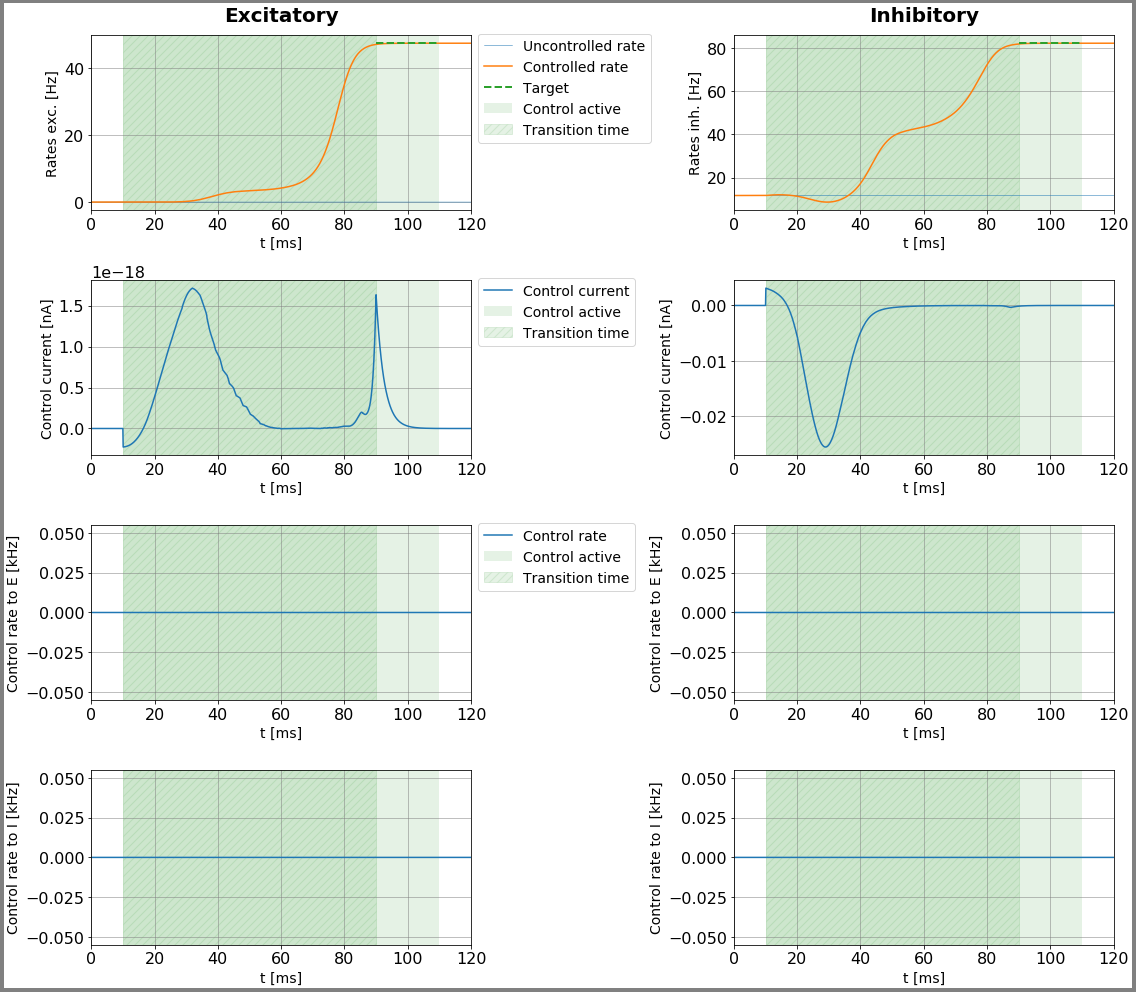

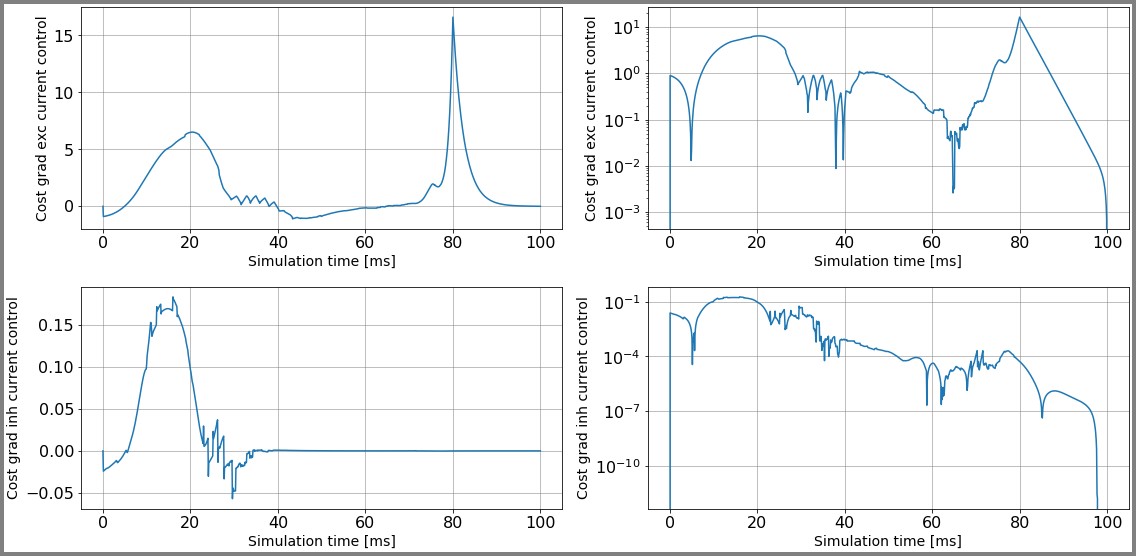

In [9]:
c_ = 2
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 4

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.0004784595881935682
Gradient descend method:  None
RUN  1 , total integrated cost =  1.7107808345502685e-06
RUN  2 , total integrated cost =  3.014130107686937e-10
RUN  3 , total integrated cost =  7.266837616893401e-19
RUN  4 , total integrated cost =  3.06160464792211e-21
RUN  5 , total integrated cost =  2.192622805921109e-22
RUN  6 , total integrated cost =  1.1025770537625734e-22
RUN  7 , total integrated cost =  8.223990804818811e-23
RUN  8 , total integrated cost =  6.268903180868024e-23
RUN  9 , total integrated cost =  1.9978814979017278e-23
RUN  10 , total integrated cost =  9.784652015126961e-26
RUN  11 , total integrated cost =  1.5254676640801828e-26
RUN  12 , total integrated cost =  4.293927679299011e-27
RUN  13 , total integrated cost =  3.657790245328787e-27
RUN  14 , total integrated cost =  3.657790245328787e-27
Control only changes 

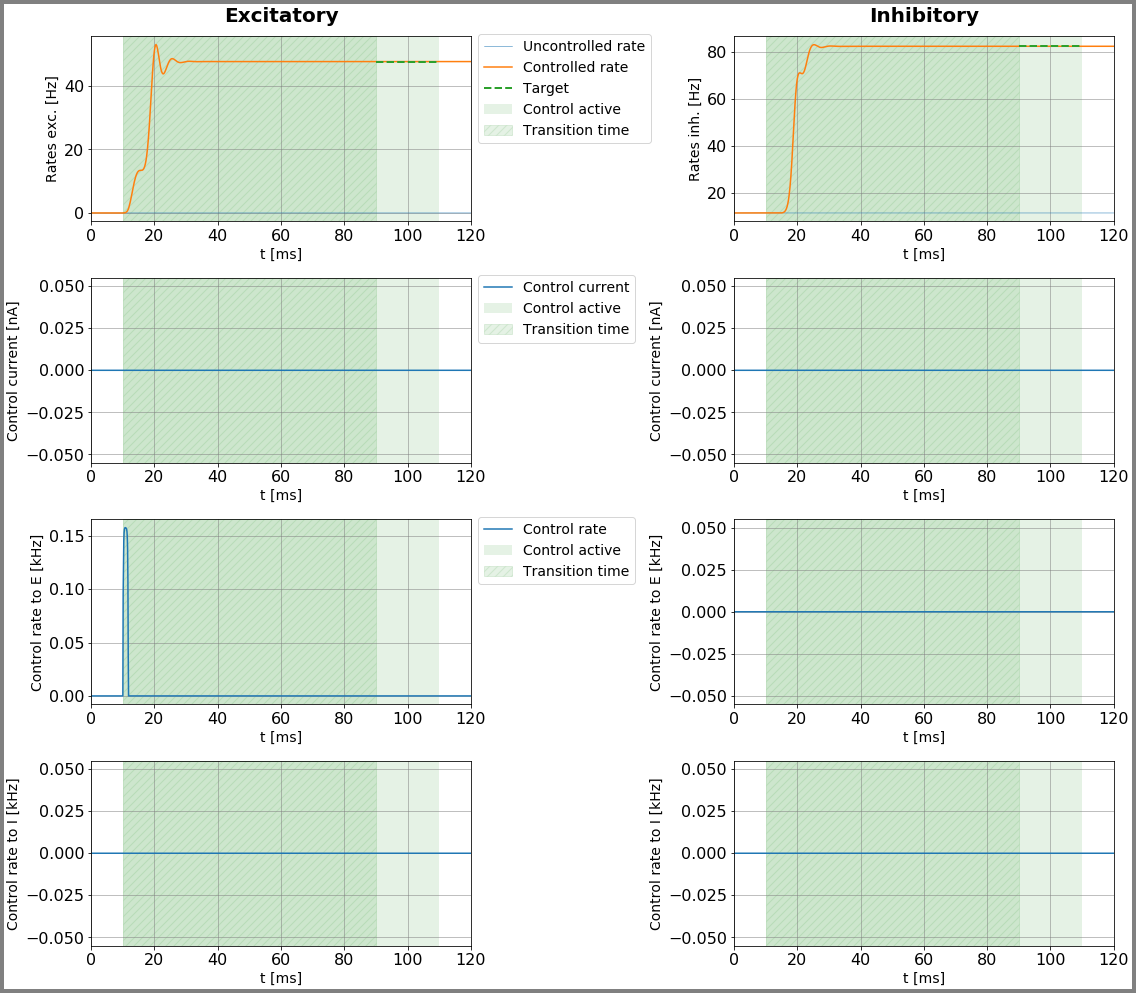

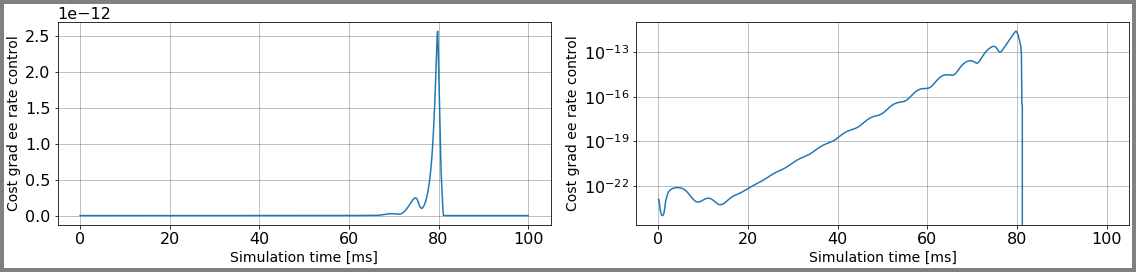

In [16]:
c_ = 3
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.6101196145997845
Gradient descend method:  None
RUN  1 , total integrated cost =  0.610119544288654
RUN  2 , total integrated cost =  0.6101194509465478
RUN  3 , total integrated cost =  0.610119381055226
RUN  4 , total integrated cost =  0.6101192878868182
RUN  5 , total integrated cost =  0.6101192184141749
RUN  6 , total integrated cost =  0.6101191254184294
RUN  7 , total integrated cost =  0.6101190563633506
RUN  8 , total integrated cost =  0.6101189635897529
RUN  9 , total integrated cost =  0.6101188948998358
RUN  10 , total integrated cost =  0.6101188023880837
RUN  11 , total integrated cost =  0.6101187316787012
RUN  12 , total integrated cost =  0.6101186408335165
RUN  13 , total integrated cost =  0.6101185677537855
RUN  14 , total integrated cost =  0.6101184771042902
RUN  15 , total integrated cost =  0.6101184043941659
RUN  16 , total i

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  689 , total integrated cost =  0.6099237242531304
Improved over  689  iterations in  30.12253899999996  seconds by  0.03210687576117266  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7144211652724582
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.1074025335343


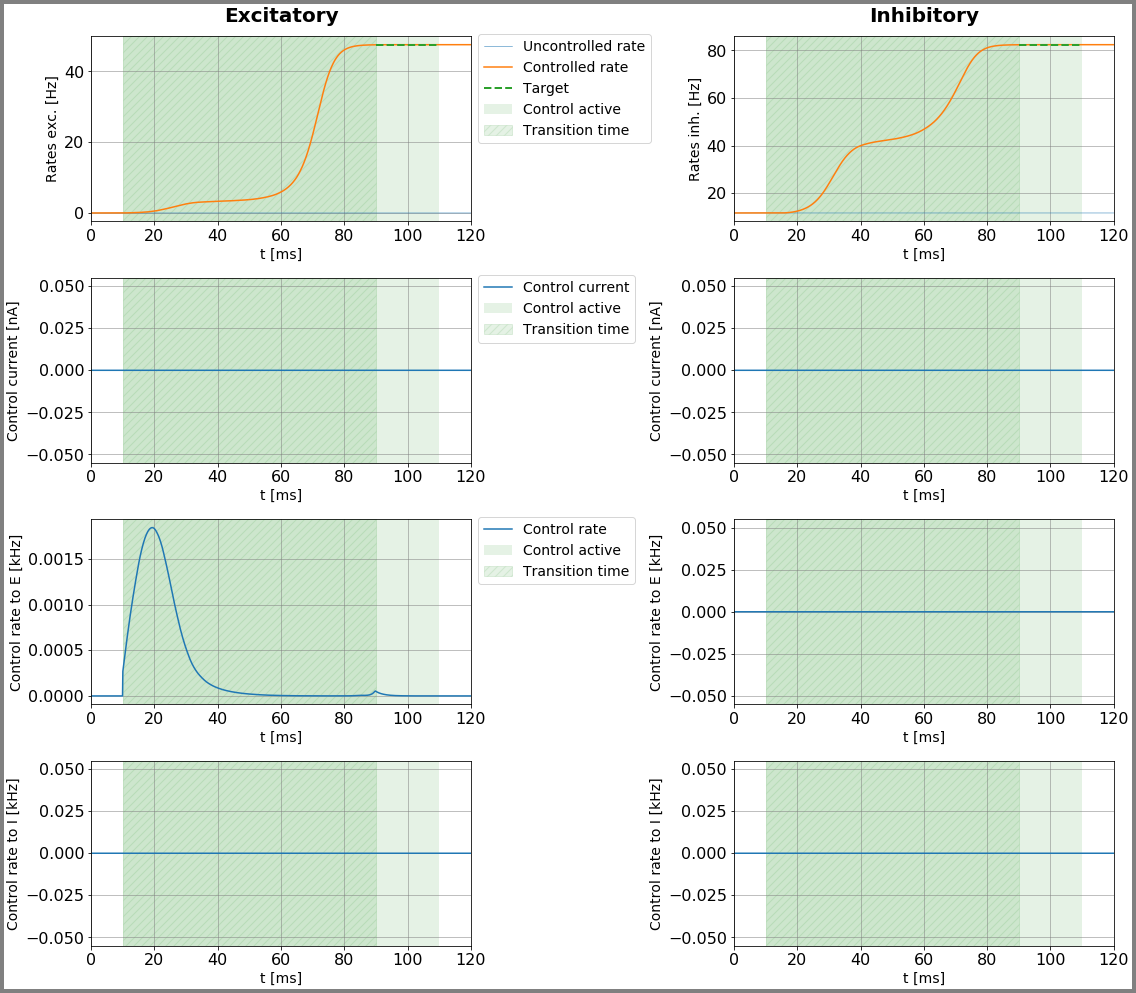

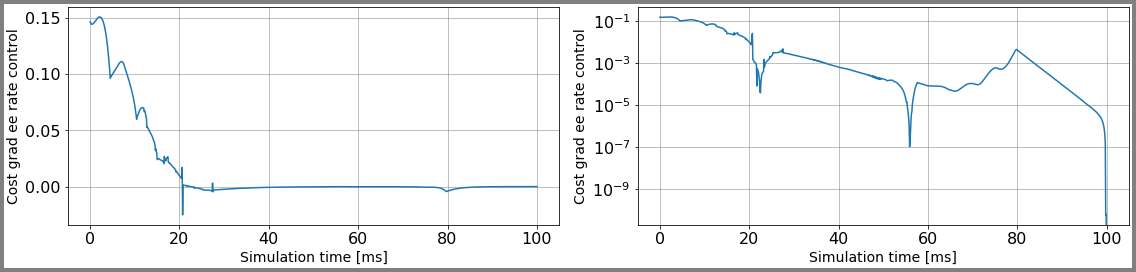

In [18]:
c_ = 3
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 5

set cost params
control input:  [3] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.280612976152
RUN  2 , total integrated cost =  22492.079399968366
RUN  3 , total integrated cost =  22492.031686706097
RUN  4 , total integrated cost =  22492.03167549877
RUN  5 , total integrated cost =  22492.03167525946
RUN  6 , total integrated cost =  22492.031675248287
RUN  7 , total integrated cost =  22492.031675248287
Control only changes marginally.
RUN  7 , total integrated cost =  22492.031675248287
Improved over  7  iterations in  0.3852332000001297  seconds by  0.00650270845935097  percent.


ERROR:root:Problem in initial value trasfer


Problem in initial value trasfer:  Vmean_exc -56.297496756120516 -56.29763532294136


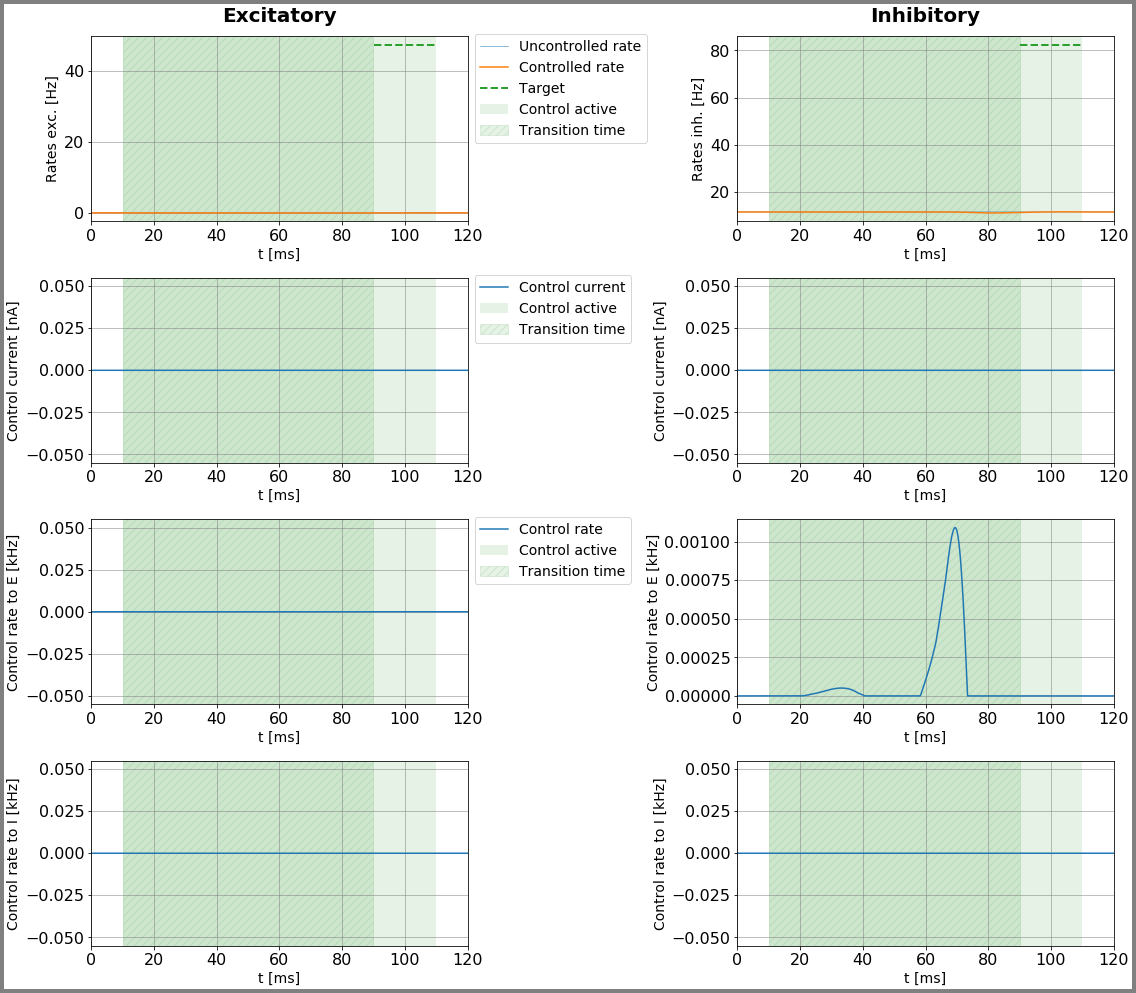

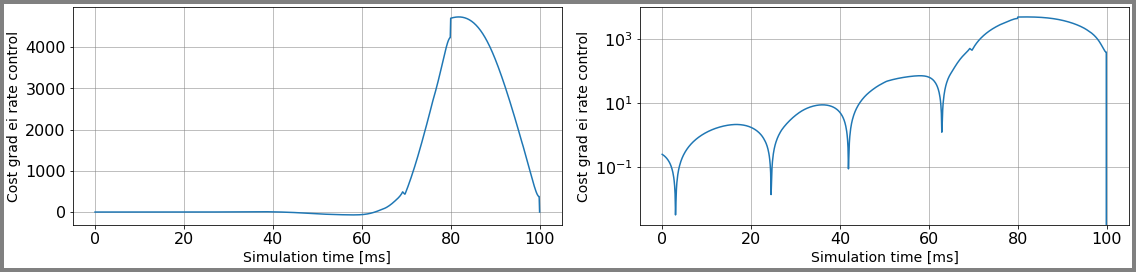

In [19]:
c_ = 4
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

ERROR:root:Problem in initial value trasfer


set cost params
control input:  [3] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22492.28720065602
Gradient descend method:  None
RUN  1 , total integrated cost =  22492.28720065602
Control only changes marginally.
RUN  1 , total integrated cost =  22492.28720065602
Improved over  1  iterations in  0.11635440000009112  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.297496756120516 -56.29763532294136


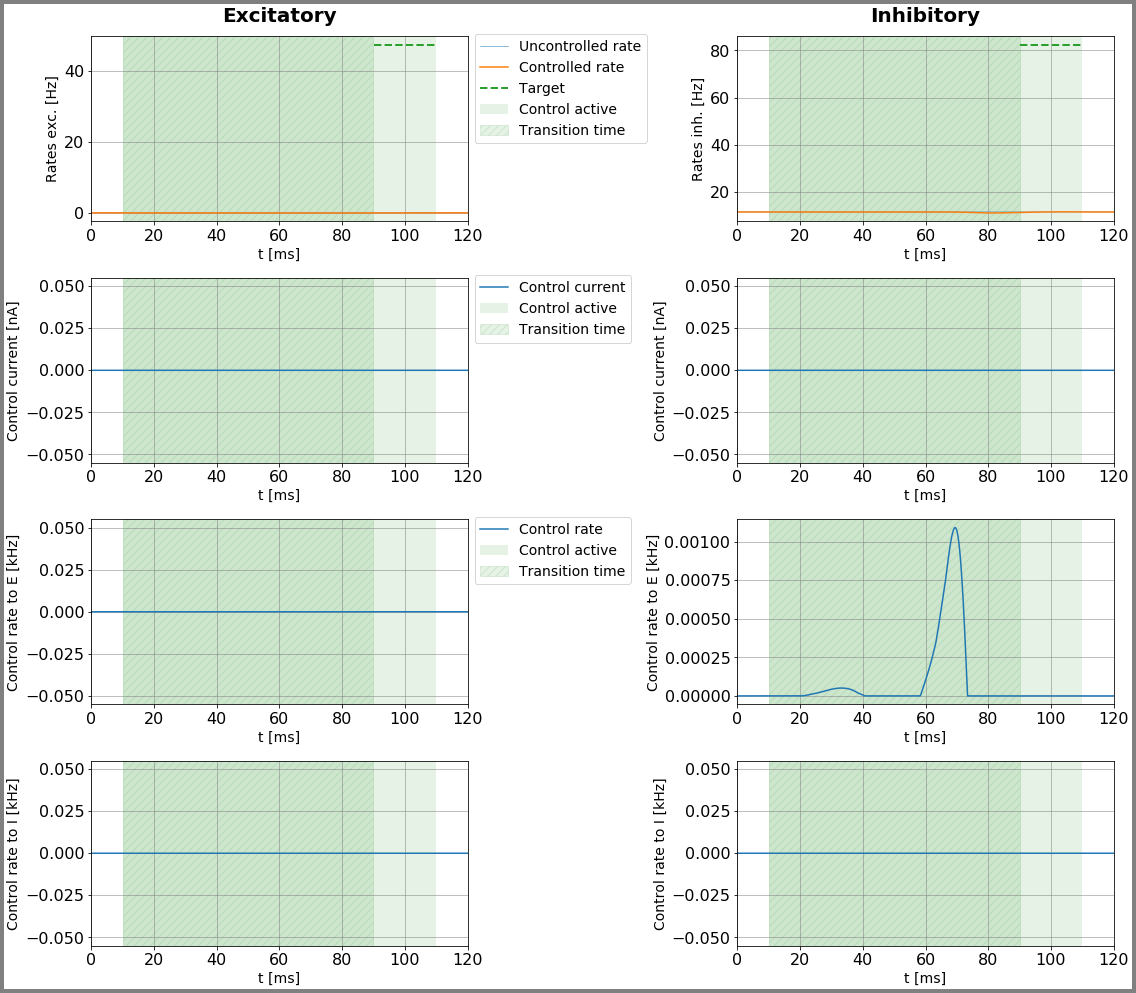

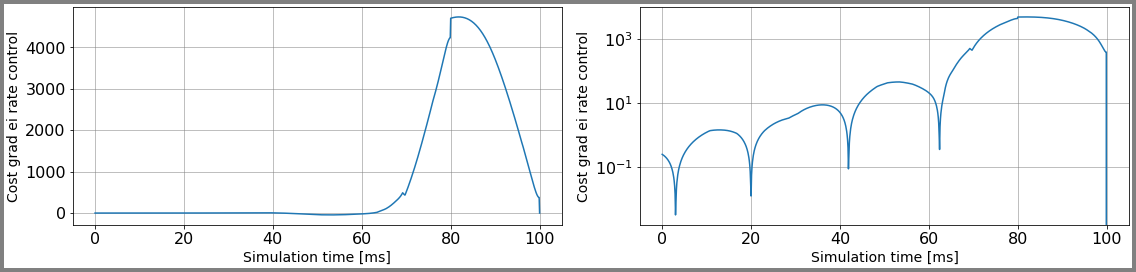

In [20]:
c_ = 4
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 6

set cost params
control input:  [4] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.17805976065
RUN  2 , total integrated cost =  22492.155394063364
RUN  3 , total integrated cost =  22492.1434416499
RUN  4 , total integrated cost =  22492.142121746077
RUN  5 , total integrated cost =  22492.142074852487
RUN  6 , total integrated cost =  22492.14206072361
RUN  7 , total integrated cost =  22492.142037173144
RUN  8 , total integrated cost =  22492.141600684343
RUN  9 , total integrated cost =  22492.13095708156
RUN  10 , total integrated cost =  22492.12962383677
RUN  11 , total integrated cost =  22492.12960673518
RUN  12 , total integrated cost =  22492.129606531304
RUN  13 , total integrated cost =  22492.129606518512
RUN  14 , total integrated cost =  22492.129606518196


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  22492.12960651819
RUN  16 , total integrated cost =  22492.129606518185
RUN  17 , total integrated cost =  22492.129606518185
Control only changes marginally.
RUN  17 , total integrated cost =  22492.129606518185
Improved over  17  iterations in  0.8018741000000773  seconds by  0.00606733248653768  percent.
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.382311344302853
Problem in initial value trasfer:  Vmean_exc -56.298296222452 -56.298423356079454


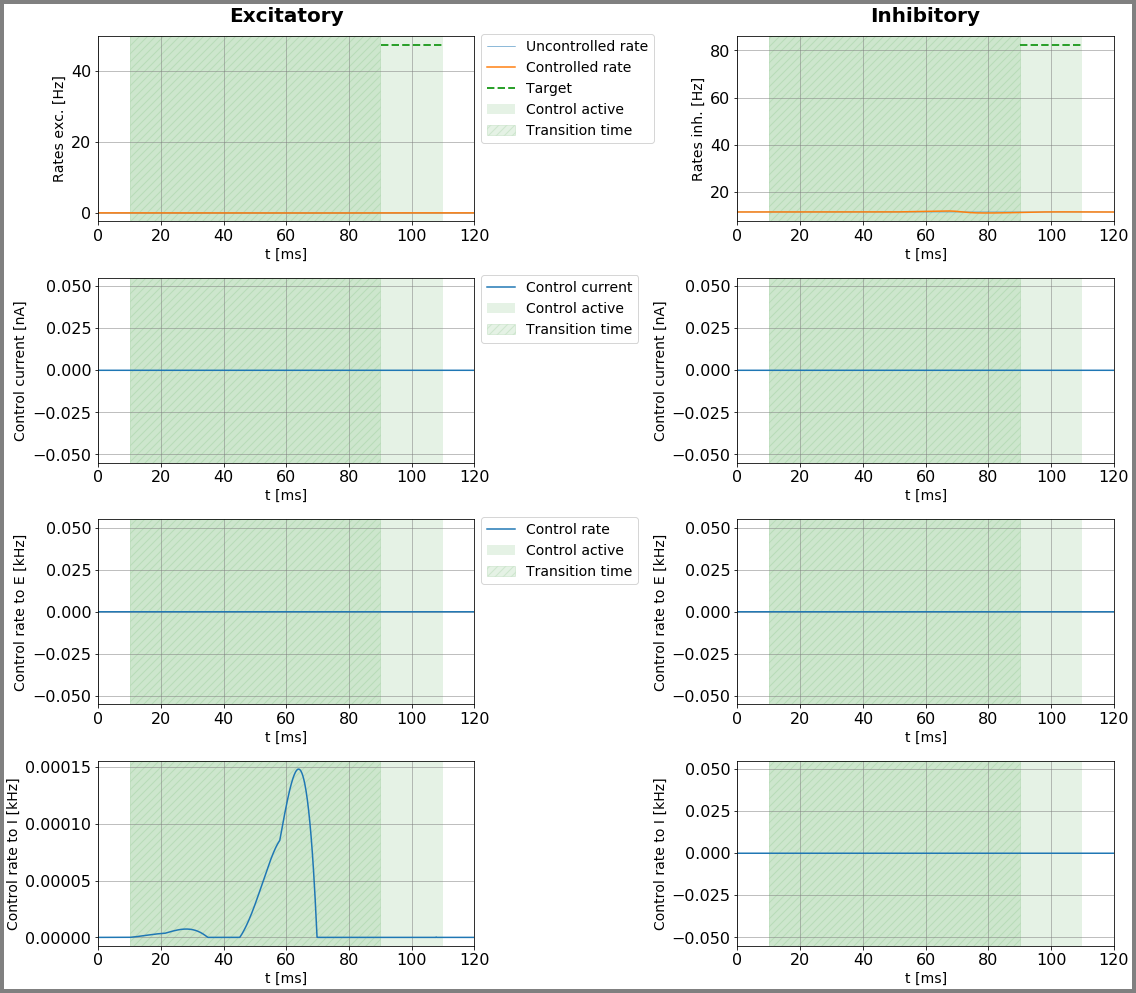

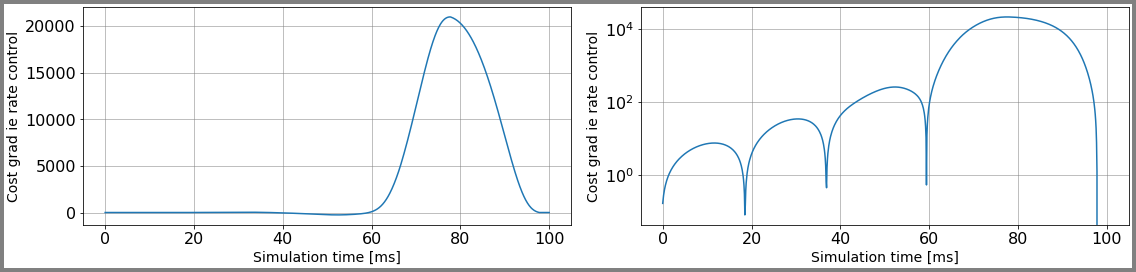

In [21]:
c_ = 5
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
control input:  [4] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22492.174363247294
Gradient descend method:  None
RUN  1 , total integrated cost =  22492.174363247294
Control only changes marginally.
RUN  1 , total integrated cost =  22492.174363247294
Improved over  1  iterations in  0.11222730000008596  seconds by  0.0  percent.
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.382311344302853
Problem in initial value trasfer:  Vmean_exc -56.298296222452 -56.298423356079454


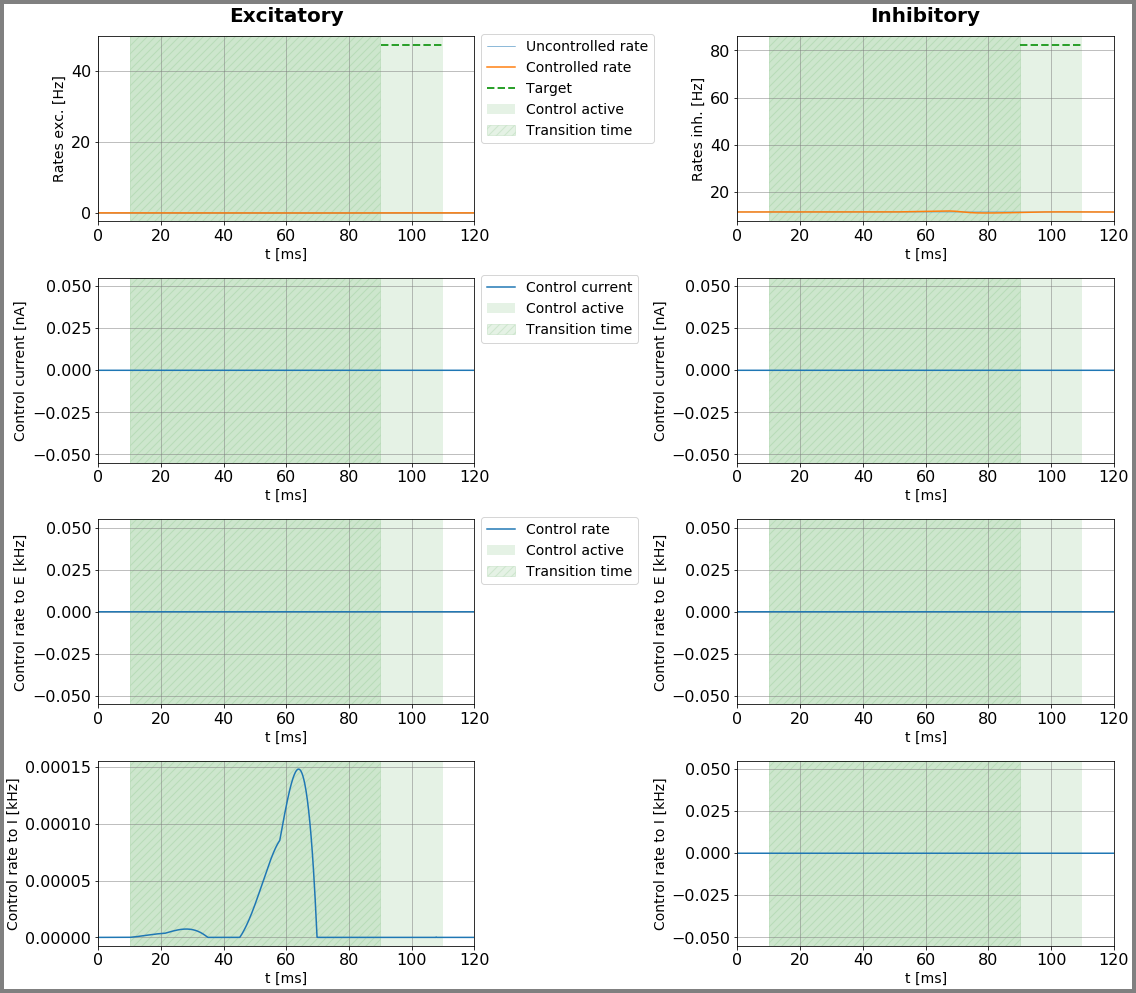

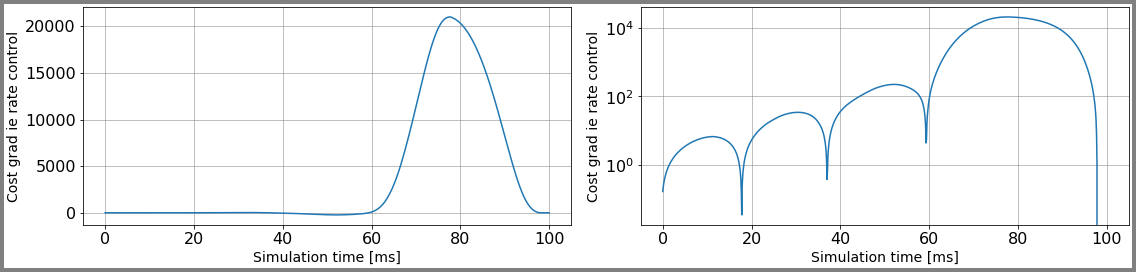

In [22]:
c_ = 5
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 7

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
control input:  [5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.2112361860864539e-14
Gradient descend method:  HS
RUN  1 , total integrated cost =  1.2112361860864539e-14
Control only changes marginally.
RUN  1 , total integrated cost =  1.2112361860864539e-14
Improved over  1  iterations in  0.07975399999986621  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmai_f 0.5540255416344939 0.5467555034483933
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.407862739802621
Problem in initial value trasfer:  Vmean_exc -56.17459178092804 -56.17459297628916


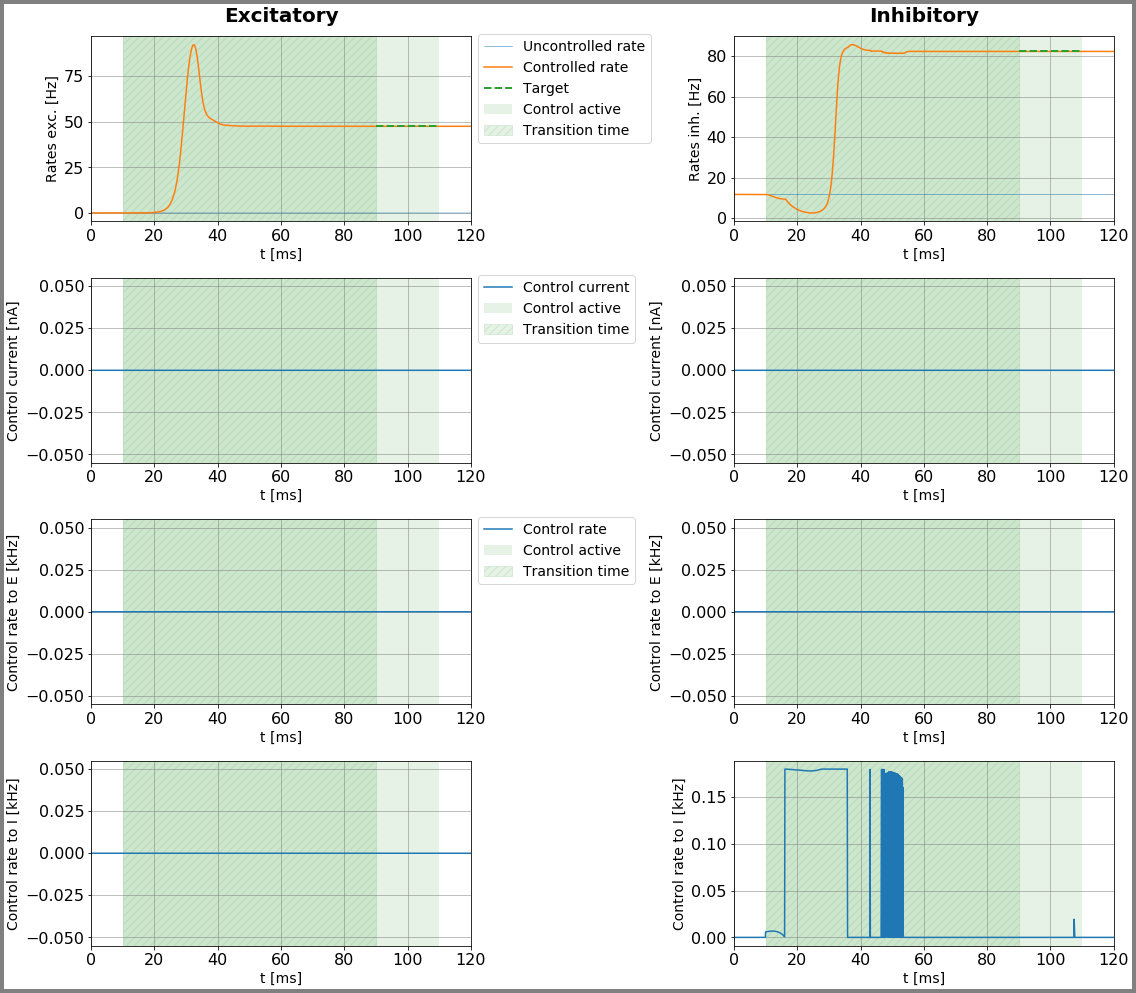

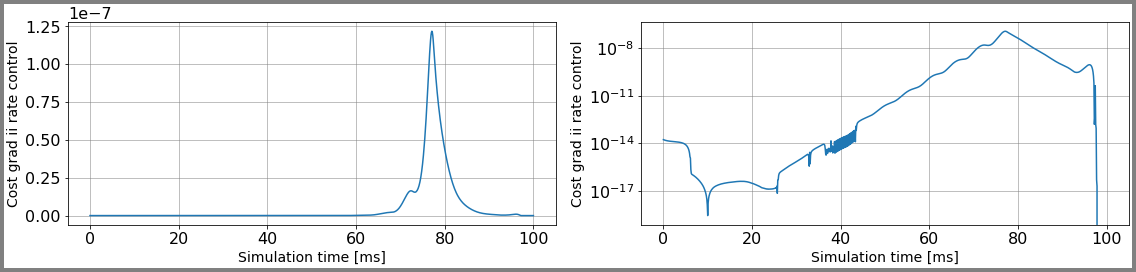

In [31]:
c_ = 6
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 100

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.3276999358686976
Gradient descend method:  None
RUN  1 , total integrated cost =  2.327699535683226
RUN  2 , total integrated cost =  2.3276990892589575
RUN  3 , total integrated cost =  2.327698771454364
RUN  4 , total integrated cost =  2.3276984308577604
RUN  5 , total integrated cost =  2.3276981435553603
RUN  6 , total integrated cost =  2.3276978106177912
RUN  7 , total integrated cost =  2.3276975181924864
RUN  8 , total integrated cost =  2.327697190181536
RUN  9 , total integrated cost =  2.327696898799363
RUN  10 , total integrated cost =  2.3276965755302252
RUN  11 , total integrated cost =  2.3276962856023777
RUN  12 , total integrated cost =  2.3276957423706977
RUN  13 , total integrated cost =  2.3276953658270507
RUN  14 , total integrated cost =  2.3276947479211256
RUN  15 , total integrated cost =  2.3276943313672973
RUN  16 , total int

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  653 , total integrated cost =  2.3273882381935844
Improved over  653  iterations in  30.422875000000204  seconds by  0.013390801379074446  percent.
Problem in initial value trasfer:  sigmai_f 0.5540255416344939 0.553008316169643
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.385886474879948
Problem in initial value trasfer:  Vmean_exc -56.174590973627986 -56.174590985491136


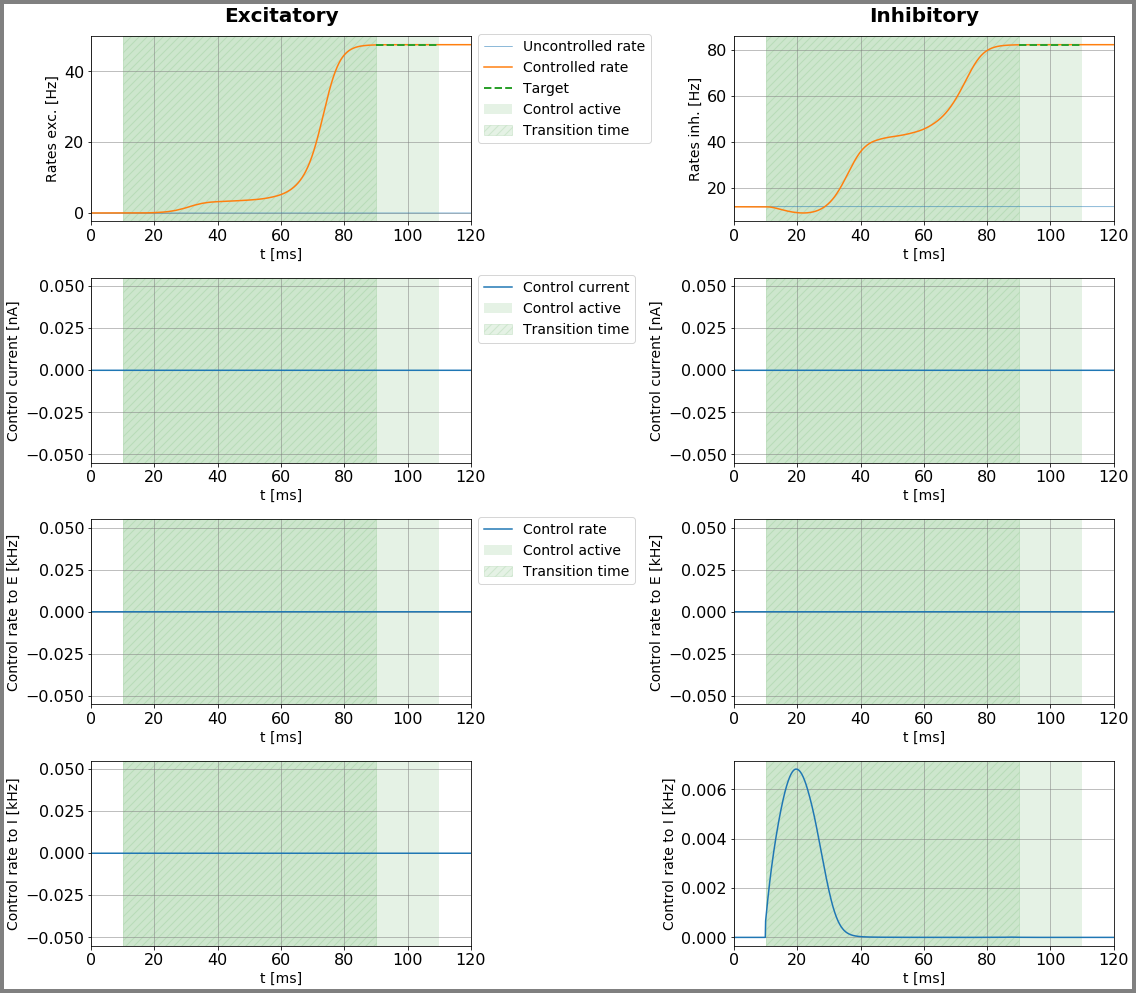

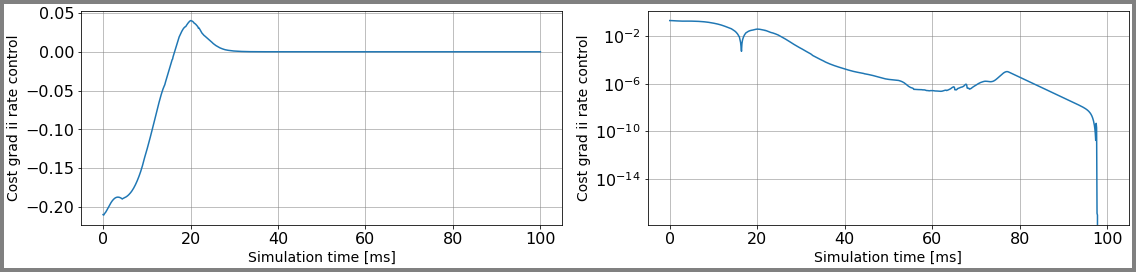

In [38]:
c_ = 6
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 8

set cost params
control input:  [2, 3, 4, 5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5.173547117722459e-12
Gradient descend method:  None
RUN  1 , total integrated cost =  5.171257805919362e-12
RUN  2 , total integrated cost =  5.167967985752597e-12
RUN  3 , total integrated cost =  5.164320028364455e-12
RUN  4 , total integrated cost =  5.16191653693548e-12
RUN  5 , total integrated cost =  5.159547623985059e-12
RUN  6 , total integrated cost =  5.157354128844185e-12
RUN  7 , total integrated cost =  5.155209283727438e-12
RUN  8 , total integrated cost =  5.152823411567769e-12
RUN  9 , total integrated cost =  5.149553804299582e-12
RUN  10 , total integrated cost =  5.147023001185566e-12
RUN  11 , total integrated cost =  5.144482833676688e-12
RUN  12 , total integrated cost =  5.1422348595309854e-12
RUN  13 , total integrated cost =  5.139920330370583e-12
RUN  14 , total integrated cost =  5.136851055627466e-12
RUN  15 , total

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3000 , total integrated cost =  1.2513999496239189e-12
RUN  3000 , total integrated cost =  1.2513999496239189e-12
Improved over  3000  iterations in  501.6475167999997  seconds by  75.81156755416156  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.6268381460250628
Problem in initial value trasfer:  sigmai_f 0.5540255416344939 0.5538635836250969
Problem in initial value trasfer:  tau_exc 27.1002330097023 30.214479642669104
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.38288053419074
Problem in initial value trasfer:  Vmean_exc -56.174591352998235 -56.17459285496076


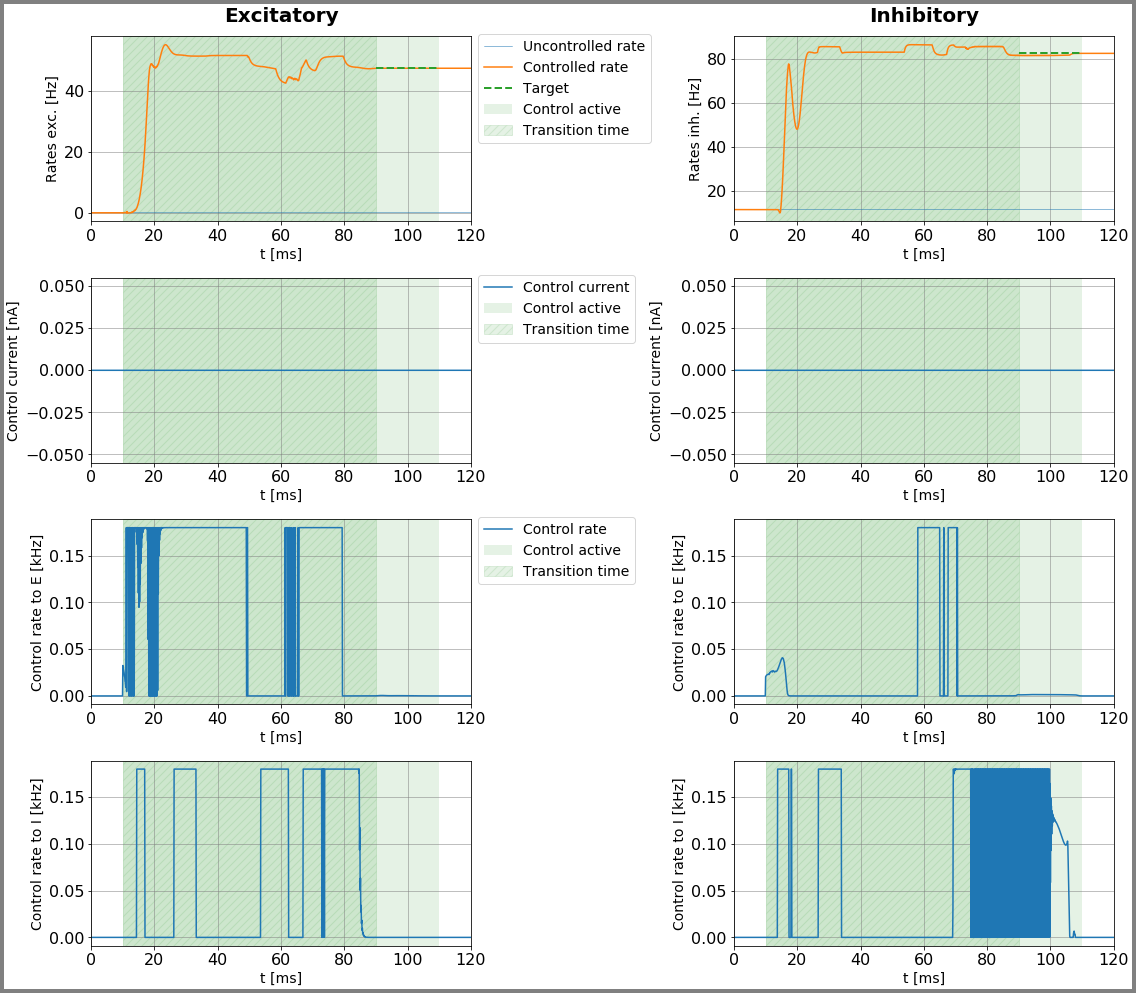

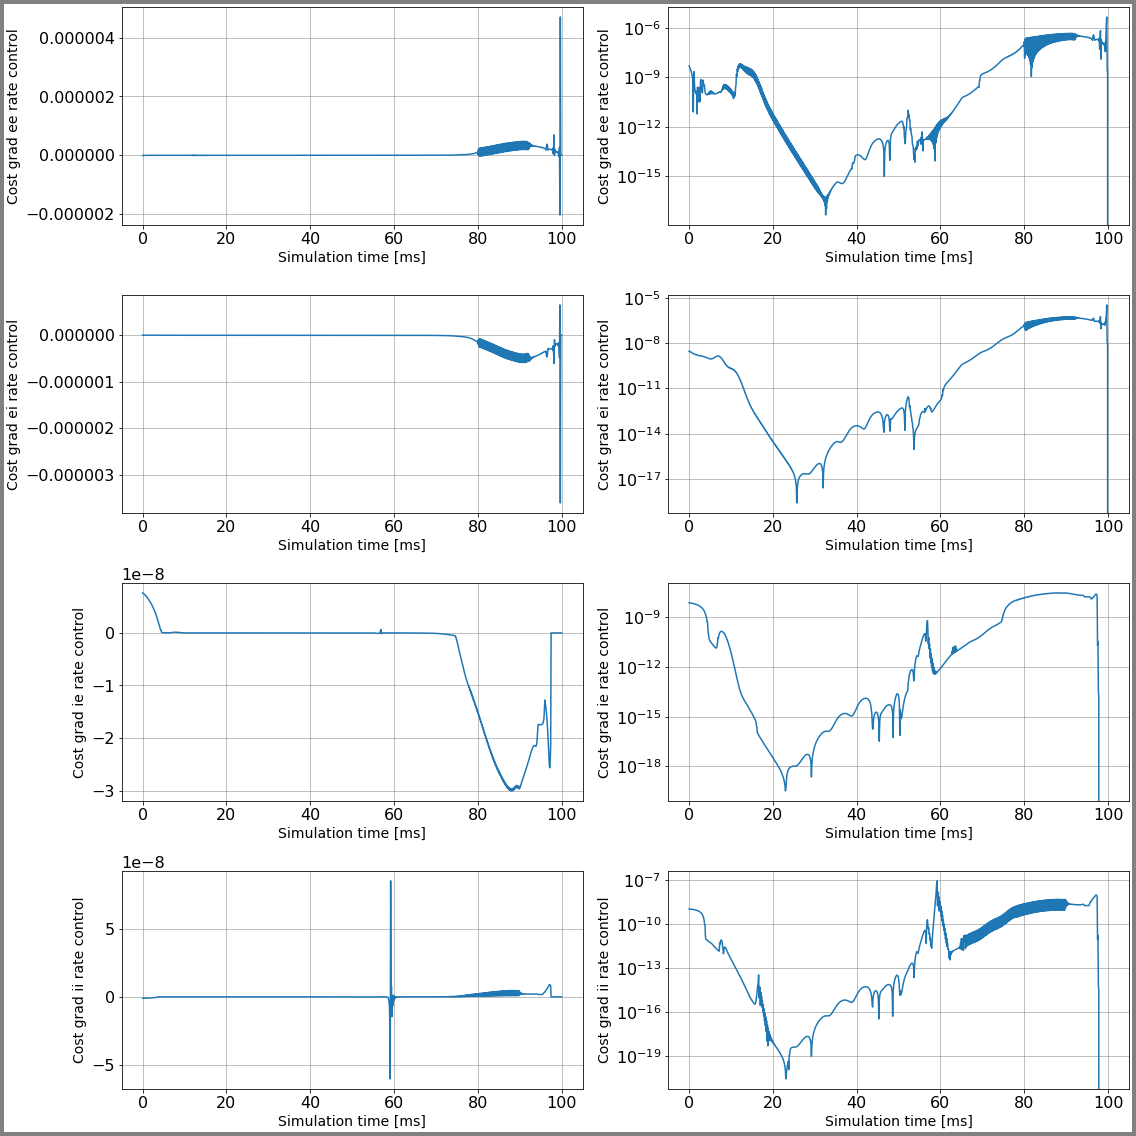

In [56]:
c_ = 7
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

cgv = None
max_it = 3000

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [2, 3, 4, 5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.6099253537845007
Gradient descend method:  None
RUN  1 , total integrated cost =  0.6099253531329233
RUN  2 , total integrated cost =  0.6099253516484378
RUN  3 , total integrated cost =  0.6099253509918289
RUN  4 , total integrated cost =  0.60992534939374
RUN  5 , total integrated cost =  0.6099253487729138
RUN  6 , total integrated cost =  0.6099253472747048
RUN  7 , total integrated cost =  0.6099253466574484
RUN  8 , total integrated cost =  0.609925345163227
RUN  9 , total integrated cost =  0.6099253445493178
RUN  10 , total integrated cost =  0.609925343059272
RUN  11 , total integrated cost =  0.6099253424484176
RUN  12 , total integrated cost =  0.6099253409627872
RUN  13 , total integrated cost =  0.6099253403546008
RUN  14 , total integrated cost =  0.609925338873742
RUN  15 , total integrated cost =  0.6099253382676962
RUN  16 , t

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  38 , total integrated cost =  0.6099247724061206
Improved over  38  iterations in  11.81797319999987  seconds by  9.531959550201918e-05  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7144834978561586
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.1052605306857


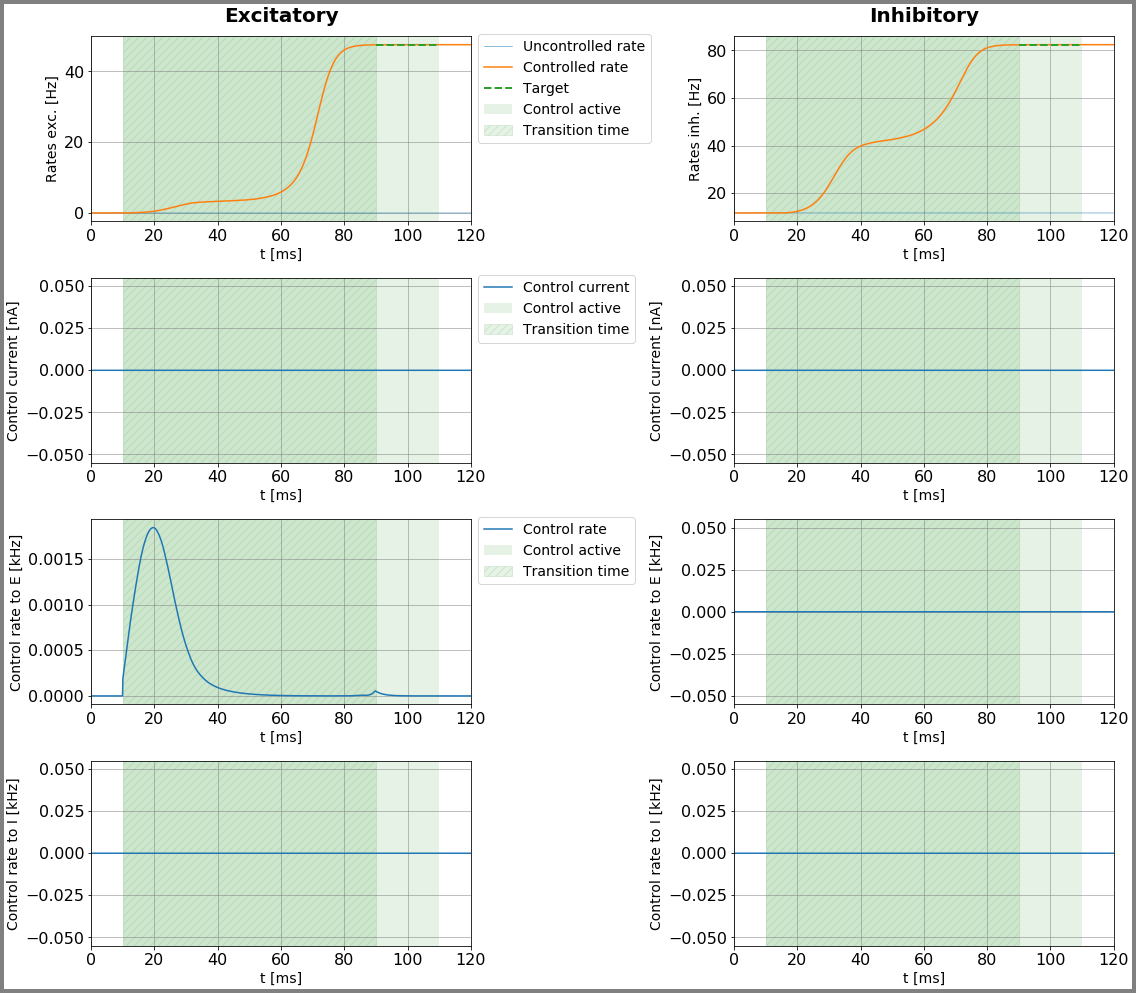

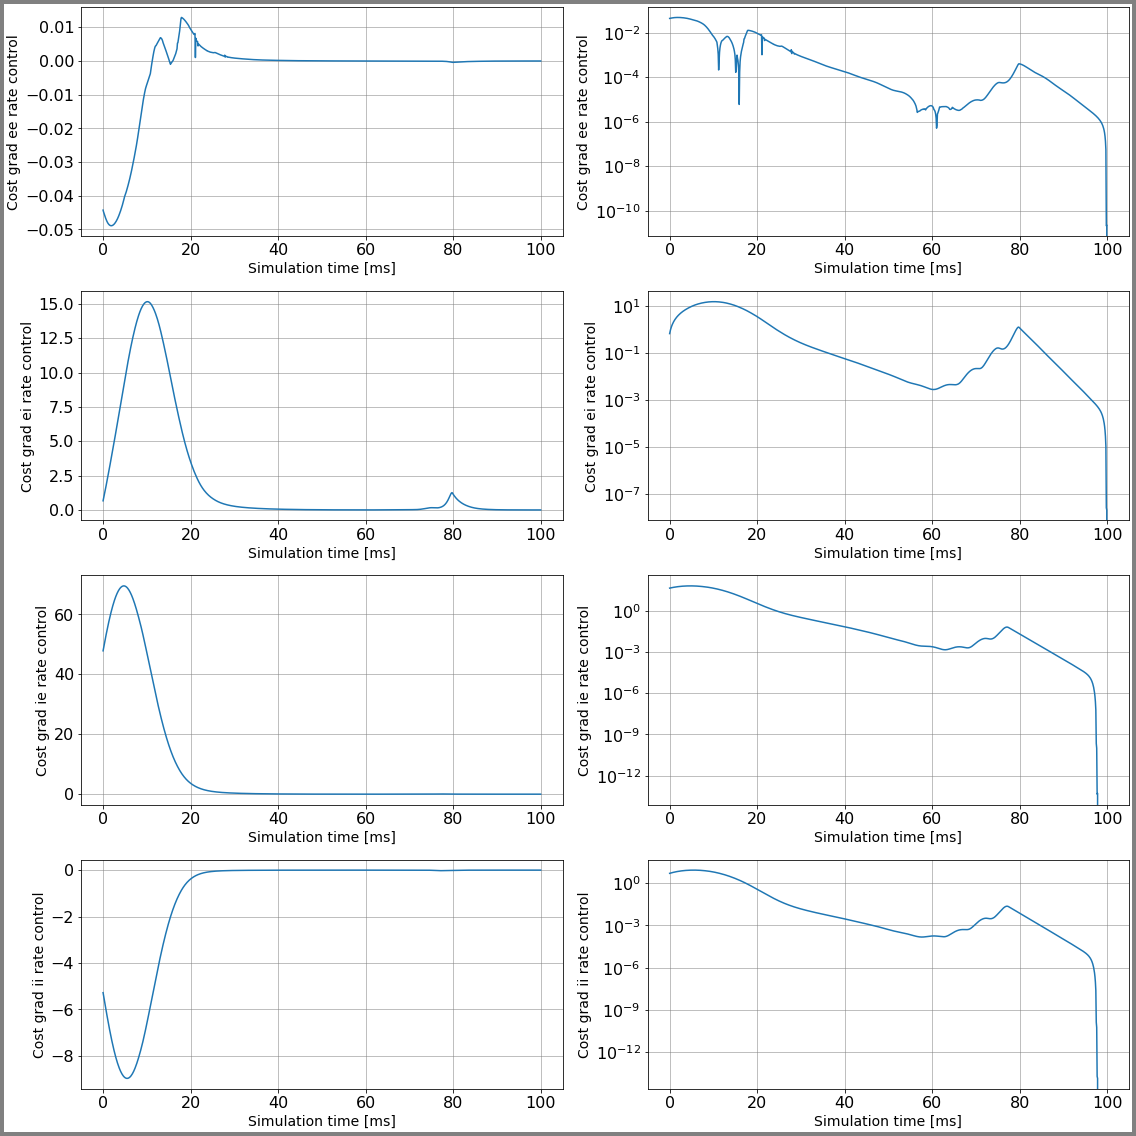

In [54]:
c_ = 7
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

In [ ]:
print("cost a")
for i in range(len(costa)):
    j = int(len(costa[i]) - 1)
    while costa[i][j] == 0.:
        j = int(j-1)
    print(costa[i][j])

print("cost b")
for i in range(len(costb)):
    j = int(len(costb[i]) - 1)
    while costb[i][j] == 0.:
        j = int(j-1)
    print(costb[i][j])